<a href="https://colab.research.google.com/github/kmkarakaya/btk_rag_bot_egitimi/blob/main/7_Ba%C4%9Flam_ve_Cevap_Olu%C5%9Fturma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 7. Bağlam ve Cevap Oluşturma

## Copyright 2025 Murat Karakaya

## 🚪Giriş ve Genel Bakış

Bu bölümde, **Erişim Destekli Metin Üretimi (Retrieval-Augmented Generation - RAG)** mimarisinin uygulama açısından en kritik iki bileşeni olan **bağlam oluşturma (context construction)** ve **cevap üretimi (answer generation)** adımlarını ele alacağız.

RAG yaklaşımında büyük dil modeli (LLM), yalnızca kendi içinde eğitildiği bilgilerle sınırlı kalmaz. Bunun yerine, harici bir bilgi tabanına erişerek kullanıcıdan gelen sorulara daha doğru, güncel ve açıklanabilir cevaplar üretir. Bu sürecin başarıyla yürütülmesi için erişilen bilgi parçalarının akıllıca yapılandırılması ve dil modeline uygun biçimde sunulması gerekir.


### 📘 Neler Öğreneceğiz?

Bu bölümde aşağıdaki kavram ve uygulamaları öğreneceğiz:

* Kullanıcı sorgusuna dayalı olarak **vektör veritabanında erişim** gerçekleştirme,
* En uygun bilgi parçalarını seçerek anlamlı bir **bağlam** oluşturma,
* Dil modeline sistem yönlendirmesi (system prompt) ile nasıl rehberlik edileceğini belirleme,
* Geliştirilen bağlamı ve sorguyu birleştirerek modelden **kontrollü, güvenilir ve kaynak odaklı cevaplar** alma.



### ❓ Neden Önemli?

Bu bölüm, RAG mimarisinde **bilginin sadece aranabilir değil, kullanılabilir** hale geldiği kritik eşiktir. Bağlam oluşturma ve cevap üretimi:

* **Erişilen bilginin etkili kullanılmasını** sağlar,
* **Uydurma (halüsinatif) yanıtları azaltır**, çünkü model sadece verilen bağlamı temel alır,
* Kurumsal uygulamalarda, kullanıcıya sunulan cevabın **kaynaklara dayalı ve izlenebilir** olmasını mümkün kılar,
* Ve tüm RAG sürecinin **doğruluğunu ve güvenilirliğini doğrudan etkiler**.

Bir sonraki bölümde bu yapının üzerine inşa edilerek, RAG mimarisiyle çalışan tam donanımlı bir sohbet botu geliştirilecektir.


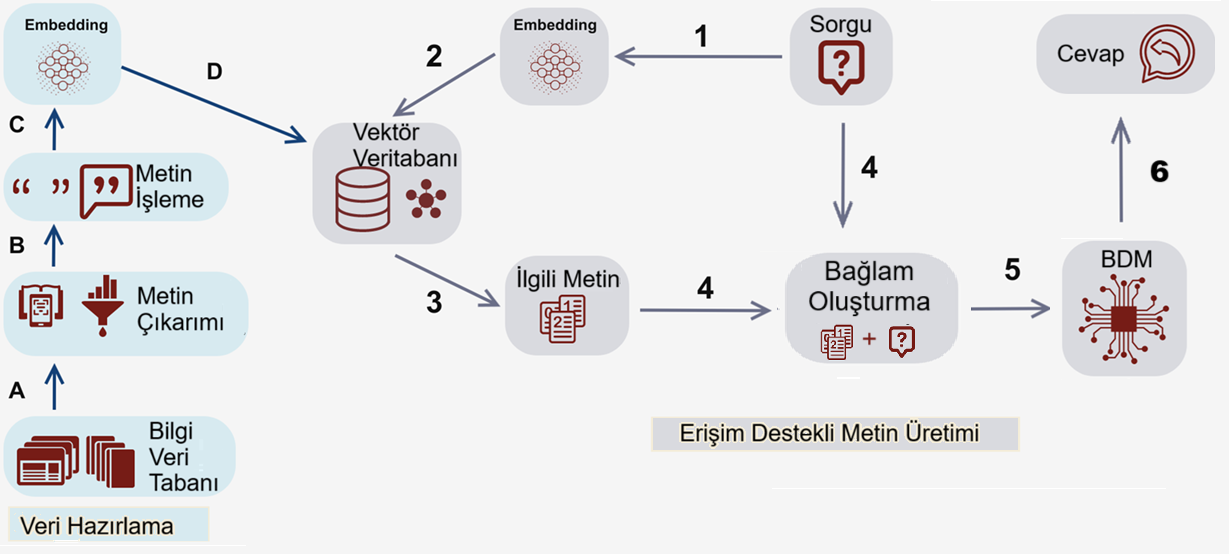

## ❓Vektör Veritabanını Sorgulama

Bir önceki bölümde, PDF belgelerinden metin çıkarımı yaparak bu metinleri önce karakter, ardından token bazlı küçük ve anlamlı parçalara ayırdık. Ardından, her bir parçayı embedding (gömme) modeli kullanarak sayısal vektörlere dönüştürdük ve bunları ChromaDB tabanlı bir vektör veritabanına kaydettik. Böylece erişim yapılabilir bir **bilgi tabanı** oluşturmuş olduk.

Bu bölümde, o oluşturduğumuz bilgi tabanına geri dönerek kullanıcıdan gelen bir sorguya **anlamsal benzerlik (semantic similarity)** temelinde nasıl erişim yapacağımızı uygulamalı olarak göreceğiz.

> 🔁 Daha önce yazdığımız kodlar artık bu adımda aktif olarak kullanılacak. Bu yüzden önceki adımlarda oluşturduğumuz tüm fonksiyonları ve değişkenleri çalıştırdığınızdan emin olun.

Şimdi:

* Bilgi tabanındaki tüm dosyaları tekrar yükleyeceğiz,
* Her bir dosya için parçalama ve gömme işlemlerini yapacağız (eğer henüz yapılmadıysa),
* Ardından, bir kullanıcı sorgusunu örnek alarak bu sorguyu embedding’e çevirip,
* Vektör veritabanı içinde semantik benzerlik temelinde sorgulayacağız.

Bu sorgulama sonucunda, kullanıcı sorusuyla **en anlamlı eşleşen** bilgi parçaları elde edilecek. Bu parçalar bir sonraki adımda modelin kullanması için bir bağlam haline getirilecek.

> 📌 Not: Bu erişim süreci, RAG sistemlerinin temelini oluşturan **semantic retrieval (anlamsal erişim)** mekanizmasının kalbidir.

Hazırsanız, önceki fonksiyonları çalıştırarak süreci başlatalım.



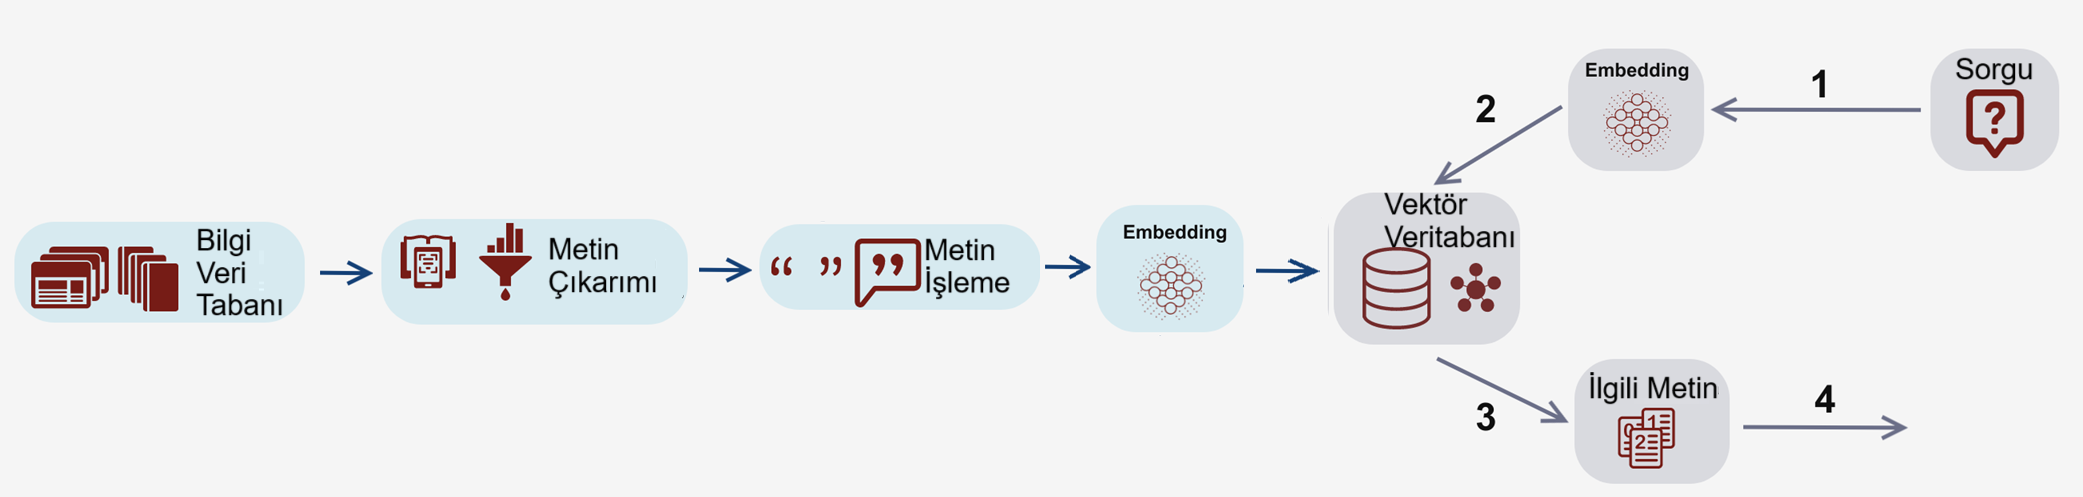

### Bilgi Tabanı (Knowledge Base) Oluştur

In [23]:
# @title Örnek Belgeleri İndir
import requests
from urllib.parse import quote

# GitHub repository bilgileri
owner = "kmkarakaya"
repo = "btk_rag_bot_egitimi"
folder_path = "Örnek Bilgi Tabanı"

# API endpoint
api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{quote(folder_path)}"

print("GitHub API'ye bağlanılıyor...")
try:
    response = requests.get(api_url)
    response.raise_for_status()

    files = response.json()
    pdf_files = [f for f in files if f['name'].lower().endswith('.pdf')]

    print(f"{len(pdf_files)} PDF dosyası bulundu:")

    downloaded_files = []

    for file in pdf_files:
        print(f"\nİndiriliyor: {file['name']}")

        try:
            file_response = requests.get(file['download_url'])
            file_response.raise_for_status()

            file_path = f"./{file['name']}"

            with open(file_path, 'wb') as f:
                f.write(file_response.content)

            file_size = len(file_response.content)
            print(f"✓ {file['name']} indirildi ({file_size:,} bytes)")
            print(f"  Konum: {file_path}")
            downloaded_files.append(file_path)

        except Exception as e:
            print(f"✗ {file['name']} indirilemedi: {e}")

    print(f"\n🎉 Toplam {len(downloaded_files)} PDF dosyası indirildi!")
    print("\nİndirilen dosyalar:")
    for file_path in downloaded_files:
        print(f"📄 {file_path}")

except Exception as e:
    print(f"API hatası: {e}")
    import traceback
    traceback.print_exc()

GitHub API'ye bağlanılıyor...
5 PDF dosyası bulundu:

İndiriliyor: CiftAnadalProgramiYonergesi.pdf
✓ CiftAnadalProgramiYonergesi.pdf indirildi (446,739 bytes)
  Konum: ./CiftAnadalProgramiYonergesi.pdf

İndiriliyor: DersMuafiyetiveIntibakIslemleriYonergesi.pdf
✓ DersMuafiyetiveIntibakIslemleriYonergesi.pdf indirildi (386,513 bytes)
  Konum: ./DersMuafiyetiveIntibakIslemleriYonergesi.pdf

İndiriliyor: DersSinavEvraklarininMuhafazasiYonergesi.pdf
✓ DersSinavEvraklarininMuhafazasiYonergesi.pdf indirildi (437,085 bytes)
  Konum: ./DersSinavEvraklarininMuhafazasiYonergesi.pdf

İndiriliyor: LisansEğitimÖğretimYönetmeliği.pdf
✓ LisansEğitimÖğretimYönetmeliği.pdf indirildi (659,368 bytes)
  Konum: ./LisansEğitimÖğretimYönetmeliği.pdf

İndiriliyor: LisansOgrencileriIcinBursYonergesi.pdf
✓ LisansOgrencileriIcinBursYonergesi.pdf indirildi (479,027 bytes)
  Konum: ./LisansOgrencileriIcinBursYonergesi.pdf

🎉 Toplam 5 PDF dosyası indirildi!

İndirilen dosyalar:
📄 ./CiftAnadalProgramiYonergesi.pdf
📄 

### PDF Belgelerini Yükle

In [24]:
import os
def create_knowledge_base():
  # İndirilen dosya yollarını tutacak boş bir liste oluşturun
  downloaded_files = []

  # Mevcut dizindeki tüm dosya ve klasörleri listele
  for item in os.listdir('.'):
      # Eğer öğe bir dosyaysa ve '.pdf' ile bitiyorsa
      if os.path.isfile(item) and item.lower().endswith('.pdf'):
          # Dosya yolunu downloaded_files listesine ekle
          downloaded_files.append(item)

  # Bulunan PDF dosyalarını yazdır
  print("Yerel dizinde bulunan PDF dosyaları:")
  for file_path in downloaded_files:
      print(f"📄 {file_path}")

  print(f"\nToplam {len(downloaded_files)} PDF dosyası bulundu.")
  return downloaded_files

### Belgelerden Metin Çıkarımı (Text Extraction):

In [25]:
%pip install -q PyPDF2
import PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 4.6 MB/s eta 0:00:00


In [26]:
def convert_PDF_Text(pdf_path):
  try:
    # Belirtilen PDF dosyasını okumak için PdfReader nesnesi oluştur
    reader = PyPDF2.PdfReader(pdf_path)
    # Her sayfadan metni çıkar ve baş/son boşlukları temizle
    pdf_pages = [p.extract_text().strip() for p in reader.pages]
    # Boş metin dizilerini filtrele
    pdf_pages = [text for text in pdf_pages if text]
    # Belge adını ve işlenen sayfa sayısını yazdır
    print("Belge: ", pdf_path,"\nSayfa Sayısı: ", len(pdf_pages))
    # Metin sayfalarının listesini döndür
    return pdf_pages
  except Exception as e:
    print(f"Hata oluştu: {pdf_path} dosyası işlenemedi. Hata: {e}")
    return [] # Hata durumunda boş liste döndür

### Metin İşleme (Chunking)

In [27]:
# Langchain kütüphanesini yükle (eğer yüklü değilse)
%pip install langchain --quiet
import langchain

# Metinleri parçalara ayırmak için gerekli sınıfları içe aktar
from langchain.text_splitter import RecursiveCharacterTextSplitter, SentenceTransformersTokenTextSplitter

In [28]:
def convert_Page_ChunkinChar(pdf_texts, chunk_size = 1500, chunk_overlap=200 ):
  # Karakter tabanlı metin ayırıcı nesnesi oluştur
  character_splitter = RecursiveCharacterTextSplitter(
      # Ayırıcı karakterleri tanımla
      separators=["\n\n", "\n", ". ", " ", ""],
      # Her parçanın maksimum karakter boyutunu belirle
      chunk_size=chunk_size,
      # Parçalar arasındaki çakışma miktarını belirle
      chunk_overlap=chunk_overlap
  )
  # PDF metinlerini belirtilen ayırıcılar ve boyutlarla parçalara ayır
  character_split_texts = character_splitter.split_text('\n\n'.join(pdf_texts))
  # Toplam parça sayısını yazdır
  print(f"\nToplam parça sayısı (belge maksimum karakter boyutuna göre bölündü = {chunk_size}): \
        {len(character_split_texts)}")
  # Oluşturulan metin parçalarının listesini döndür
  return character_split_texts

In [29]:
# sentence_transformers kütüphanesini yükle (eğer yüklü değillerse)
# sentence_transformers: Metinleri vektörlere dönüştürmek için kullanılır (embedding).
#%pip install sentence_transformers --quiet

In [30]:
# Metinleri token bazlı parçalara ayırmak için gerekli sınıfı içe aktar
from langchain.text_splitter import SentenceTransformersTokenTextSplitter

# Kullanılacak Sentence Transformer modelinin adını tanımla
# Bu model, metin parçalarını tokenlara ayırmak ve embedding işlemi için kullanılacak.
sentence_transformer_model="distiluse-base-multilingual-cased-v1"

In [31]:
# Metinleri token bazlı parçalara ayıran yardımcı fonksiyon
def convert_Chunk_Token(text_chunksinChar,sentence_transformer_model, chunk_overlap=10,tokens_per_chunk=128 ):
  # SentenceTransformersTokenTextSplitter nesnesi oluşturuluyor
  token_splitter = SentenceTransformersTokenTextSplitter(
      chunk_overlap=chunk_overlap, # Parçalar arası çakışma miktarı
      model_name=sentence_transformer_model, # Kullanılacak tokenizer modelinin adı
      tokens_per_chunk=tokens_per_chunk) # Her bir parçadaki maksimum token sayısı

  # Tokenlara ayrılmış metin parçalarını tutacak boş liste
  text_chunksinTokens = []
  # Karakter bazlı parçalar üzerinde döngü
  for text in text_chunksinChar:
      # Her bir karakter bazlı parçayı tokenlara ayır ve listeye ekle
      text_chunksinTokens += token_splitter.split_text(text)
  # Bilgilendirme mesajı yazdır
  print(f"""\nBelge {tokens_per_chunk} token'lık parçalara bölündüğünde,
  ve çakışma token sayısı {chunk_overlap} olduğunda
  toplam parça sayısı: {len(text_chunksinTokens)}""")
  # Tokenlara ayrılmış metin parçaları listesini döndür
  return text_chunksinTokens

### Vektör Veritabanı Hazırla

In [13]:
!pip install -q chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 4.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.1/103.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.6/201.6 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.1 MB/s eta 

In [14]:
import chromadb
# Vektör veritabanı için dosya yolu belirle
vector_database_path = "./" # Mevcut dizini kullan

In [15]:
from chromadb.utils import embedding_functions
# SentenceTransformer modelini kullanarak bir embedding fonksiyonu oluştur
# Bu fonksiyon, metin parçalarını vektörlere dönüştürmek için kullanılacak

# önce embedding modelini seç
sentence_transformer_model="distiluse-base-multilingual-cased-v1"
# sonra fonksiyonu oluştur
embedding_function= embedding_functions.SentenceTransformerEmbeddingFunction(model_name=sentence_transformer_model)

modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/556 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

2_Dense/pytorch_model.bin:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

In [16]:
def create_chroma_client(vector_database_path, collection_name, embedding_function):
  # Kalıcı (Persistent) bir ChromaDB istemcisi oluştur
  # Bu, vektör veritabanının diske kaydedilmesini ve oturumlar arasında kalıcı olmasını sağlar
  chroma_client = chromadb.PersistentClient(path=vector_database_path)

  # Belirtilen isimde bir koleksiyonun var olup olmadığını kontrol et
  try:
      chroma_collection = chroma_client.get_collection(collection_name)
      print(f"'{collection_name}' adlı koleksiyon zaten mevcut. Siliniyor...")
      # Eğer koleksiyon mevcutsa sil
      chroma_client.delete_collection(collection_name)
      print(f"'{collection_name}' adlı koleksiyon silindi.")
      # Silme işleminden sonra koleksiyonu yeniden oluştur
      chroma_collection = chroma_client.create_collection(collection_name, embedding_function=embedding_function)
      print(f"'{collection_name}' adlı koleksiyon yeniden oluşturuldu.")
  except:
      # Eğer koleksiyon mevcut değilse, doğrudan oluştur
      chroma_collection = chroma_client.create_collection(collection_name, embedding_function=embedding_function)
      print(f"'{collection_name}' adlı yeni koleksiyon oluşturuldu.")


  # Oluşturulan istemciyi ve koleksiyonu döndür
  return chroma_client, chroma_collection

In [17]:
def add_meta_data(text_chunksinTokens, title, category, initial_id):
  # Parçalar için benzersiz kimlikler (ID'ler) oluştur
  ids = [str(i+initial_id) for i in range(len(text_chunksinTokens))]
  # Parçalara eklenecek metadata (üst veri) sözlüğü oluştur
  metadata = {
      'document': title,  # Belge adı
      'category': category # Belge kategorisi
  }
  # Her parça için aynı metadata'yı içeren bir liste oluştur
  metadatas = [ metadata for i in range(len(text_chunksinTokens))]
  # Oluşturulan ID'ler ve metadata listelerini döndür
  return ids, metadatas

In [18]:
def add_document_to_collection(ids, metadatas, text_chunksinTokens, chroma_collection):
  # Ekleme işleminden önceki koleksiyon boyutunu yazdır
  print("Ekleme işleminden önceki koleksiyon boyutu: ", chroma_collection.count())
  # Belgeleri, metadata ve ID'leri belirterek ChromaDB koleksiyonuna ekle
  chroma_collection.add(ids=ids, metadatas= metadatas, documents=text_chunksinTokens)
  # Ekleme işleminden sonraki koleksiyon boyutunu yazdır
  print("Ekleme işleminden sonraki koleksiyon boyutu: ", chroma_collection.count())
  # Güncellenmiş koleksiyon nesnesini döndür
  return chroma_collection

### İş Akışını Tasarla

In [19]:
def load_multiple_pdfs_to_ChromaDB(collection_name,sentence_transformer_model):
  # Koleksiyon adını belirle
  collection_name= collection_name
  # Kategori adını belirle
  category= "Ogrenci Yonergeleri"
  # Kullanılacak Sentence Transformer modelini belirle
  sentence_transformer_model=sentence_transformer_model
  # Embedding fonksiyonunu oluştur
  embedding_function= embedding_functions.SentenceTransformerEmbeddingFunction(model_name=sentence_transformer_model)
  # ChromaDB istemcisi ve koleksiyonunu oluştur veya al
  chroma_client, chroma_collection = create_chroma_client(vector_database_path, collection_name, embedding_function)
  # Mevcut koleksiyonun boyutunu al (ID'leri başlatmak için)
  current_id = chroma_collection.count()
  # Bilgi tabanındaki dosya isimlerini al
  file_names = create_knowledge_base()
  # Her dosya için döngü
  for file_name in file_names:
    # Belge işleme başlangıç mesajı
    print(f"\n📖 {file_name}, {chroma_collection.name} koleksiyonuna eklenmek üzere işleniyor. Kolleksiyondaki mevcut parça sayısı: {chroma_collection.count()}")
    print(f"\n📚 Kolleksiyondaki mevcut parça sayısı: {chroma_collection.count()}")
    # Başlangıç ID'sini yazdır
    print(f"\tBaşlangıç ID: {current_id} ")
    # PDF metnini sayfa sayfa çıkar
    pdf_texts = convert_PDF_Text(file_name)
    # Metni karakter bazlı parçalara ayır
    text_chunksinChar = convert_Page_ChunkinChar(pdf_texts)
    # Karakter bazlı parçaları token bazlı parçalara ayır
    text_chunksinTokens = convert_Chunk_Token(text_chunksinChar,sentence_transformer_model)
    # Metadata ve ID'leri hazırla
    ids,metadatas = add_meta_data(text_chunksinTokens,file_name,category, current_id)
    # Sonraki belge için başlangıç ID'sini güncelle
    current_id = current_id + len(text_chunksinTokens)
    # Belgeleri ChromaDB koleksiyonuna ekle
    chroma_collection = add_document_to_collection(ids, metadatas, text_chunksinTokens, chroma_collection)
    # Belgenin eklendiğine dair mesaj ve güncel parça sayısını yazdır
    print(f"📖{file_name} koleksiyona eklendi. Kolleksiyondaki mevcut parça sayısı: {chroma_collection.count()}\n")

  print(f"📚Koleksiyona belgeler yüklendi👍\n")
  print(f"📚Kolleksiyondaki mevcut parça sayısı: {chroma_collection.count()}\n")
  # ChromaDB istemcisi ve koleksiyonunu döndür
  return  chroma_client, chroma_collection

### İş Akışını Çalıştır

In [32]:
collection_name = "Yonergeler"

In [33]:
chroma_client, chroma_collection= load_multiple_pdfs_to_ChromaDB(collection_name,sentence_transformer_model)

'Yonergeler' adlı koleksiyon zaten mevcut. Siliniyor...
'Yonergeler' adlı koleksiyon silindi.
'Yonergeler' adlı koleksiyon yeniden oluşturuldu.
Yerel dizinde bulunan PDF dosyaları:
📄 DersSinavEvraklarininMuhafazasiYonergesi.pdf
📄 CiftAnadalProgramiYonergesi.pdf
📄 DersMuafiyetiveIntibakIslemleriYonergesi.pdf
📄 LisansEğitimÖğretimYönetmeliği.pdf
📄 LisansOgrencileriIcinBursYonergesi.pdf

Toplam 5 PDF dosyası bulundu.

📖 DersSinavEvraklarininMuhafazasiYonergesi.pdf, Yonergeler koleksiyonuna eklenmek üzere işleniyor. Kolleksiyondaki mevcut parça sayısı: 0

📚 Kolleksiyondaki mevcut parça sayısı: 0
	Başlangıç ID: 0 
Belge:  DersSinavEvraklarininMuhafazasiYonergesi.pdf 
Sayfa Sayısı:  3

Toplam parça sayısı (belge maksimum karakter boyutuna göre bölündü = 1500):         5

Belge 128 token'lık parçalara bölündüğünde,
  ve çakışma token sayısı 10 olduğunda
  toplam parça sayısı: 22
Ekleme işleminden önceki koleksiyon boyutu:  0


Ekleme işleminden sonraki koleksiyon boyutu:  22
📖DersSinavEvraklarininMuhafazasiYonergesi.pdf koleksiyona eklendi. Kolleksiyondaki mevcut parça sayısı: 22


📖 CiftAnadalProgramiYonergesi.pdf, Yonergeler koleksiyonuna eklenmek üzere işleniyor. Kolleksiyondaki mevcut parça sayısı: 22

📚 Kolleksiyondaki mevcut parça sayısı: 22
	Başlangıç ID: 22 
Belge:  CiftAnadalProgramiYonergesi.pdf 
Sayfa Sayısı:  6

Toplam parça sayısı (belge maksimum karakter boyutuna göre bölündü = 1500):         11

Belge 128 token'lık parçalara bölündüğünde,
  ve çakışma token sayısı 10 olduğunda
  toplam parça sayısı: 42
Ekleme işleminden önceki koleksiyon boyutu:  22


Ekleme işleminden sonraki koleksiyon boyutu:  64
📖CiftAnadalProgramiYonergesi.pdf koleksiyona eklendi. Kolleksiyondaki mevcut parça sayısı: 64


📖 DersMuafiyetiveIntibakIslemleriYonergesi.pdf, Yonergeler koleksiyonuna eklenmek üzere işleniyor. Kolleksiyondaki mevcut parça sayısı: 64

📚 Kolleksiyondaki mevcut parça sayısı: 64
	Başlangıç ID: 64 
Belge:  DersMuafiyetiveIntibakIslemleriYonergesi.pdf 
Sayfa Sayısı:  9

Toplam parça sayısı (belge maksimum karakter boyutuna göre bölündü = 1500):         17

Belge 128 token'lık parçalara bölündüğünde,
  ve çakışma token sayısı 10 olduğunda
  toplam parça sayısı: 60
Ekleme işleminden önceki koleksiyon boyutu:  64


Ekleme işleminden sonraki koleksiyon boyutu:  124
📖DersMuafiyetiveIntibakIslemleriYonergesi.pdf koleksiyona eklendi. Kolleksiyondaki mevcut parça sayısı: 124


📖 LisansEğitimÖğretimYönetmeliği.pdf, Yonergeler koleksiyonuna eklenmek üzere işleniyor. Kolleksiyondaki mevcut parça sayısı: 124

📚 Kolleksiyondaki mevcut parça sayısı: 124
	Başlangıç ID: 124 
Belge:  LisansEğitimÖğretimYönetmeliği.pdf 
Sayfa Sayısı:  10

Toplam parça sayısı (belge maksimum karakter boyutuna göre bölündü = 1500):         36

Belge 128 token'lık parçalara bölündüğünde,
  ve çakışma token sayısı 10 olduğunda
  toplam parça sayısı: 127
Ekleme işleminden önceki koleksiyon boyutu:  124


Ekleme işleminden sonraki koleksiyon boyutu:  251
📖LisansEğitimÖğretimYönetmeliği.pdf koleksiyona eklendi. Kolleksiyondaki mevcut parça sayısı: 251


📖 LisansOgrencileriIcinBursYonergesi.pdf, Yonergeler koleksiyonuna eklenmek üzere işleniyor. Kolleksiyondaki mevcut parça sayısı: 251

📚 Kolleksiyondaki mevcut parça sayısı: 251
	Başlangıç ID: 251 
Belge:  LisansOgrencileriIcinBursYonergesi.pdf 
Sayfa Sayısı:  10

Toplam parça sayısı (belge maksimum karakter boyutuna göre bölündü = 1500):         21

Belge 128 token'lık parçalara bölündüğünde,
  ve çakışma token sayısı 10 olduğunda
  toplam parça sayısı: 78
Ekleme işleminden önceki koleksiyon boyutu:  251
Ekleme işleminden sonraki koleksiyon boyutu:  329
📖LisansOgrencileriIcinBursYonergesi.pdf koleksiyona eklendi. Kolleksiyondaki mevcut parça sayısı: 329

📚Koleksiyona belgeler yüklendi👍

📚Kolleksiyondaki mevcut parça sayısı: 329



### Sorgulama yap

In [34]:
sample_queries=[
    "Muafiyet hakkından vazgeçmek isteyen bir öğrenci nasıl bir başvuru yapmalıdır?",
    "Muafiyetten feragat eden öğrenci tekrar başvuru yapabilir mi?",
    "Lisans ders grupları ve kontenjanlar kim tarafından belirlenir?",
    "Muafiyet başvurusu nasıl yapılır?", # NOTE: Chunk'larda feragat süreci anlatılıyor, başvuru süreci değil.
    "Öğrencinin muafiyet hakkı kaç kere kullanılabilir?" # NOTE: Tekrar başvuru yasağı var ama kullanım sayısı hakkında bilgi yok.
]

In [35]:
query_no=2
print(f"Sorgu: {sample_queries[query_no]}")
chroma_collection.query(
    query_texts=sample_queries[query_no],
    n_results=5,  # Specify the number of results (top k)
)

Sorgu: Lisans ders grupları ve kontenjanlar kim tarafından belirlenir?


{'ids': [['227', '131', '140', '175', '220']],
 'embeddings': None,
 'documents': [['esaslar Senato tarafından belirlenir. e ) Yan dal sertifikası ; yan dal progra mını başarı ile tamamlayan öğrencilere anadal lisans programından mezuniyet koşullarını sağladıktan sonra verilir. Bu bir sertifika olup hiç bir programın diploması yerine geçmez. f ) Not çizelgesi ( transkript ) ; öğrencilerin öğrenimleri boyunca almış oldukl arı dersleri, derslerin kredilerini, harf notlarını, yarıyıl not ortalamalarını, genel not orta',
   '##lanır. Senato tarafından uygun görülmesi halinde lisans programlarındaki bazı dersler uzaktan öğretim yoluyla verileb ilir. Verilecek derslerin grupları, kapasiteleri ve derslere ilişkin koşullar ilgili bölüm başkanlıkları tarafından belirlenir. Ders programları EFPDO tarafından düzenlenerek ÖİM tarafından ilan edilir. ( 5 ) Bir eğitim - öğretim yılındaki kayıt, ders, sınav v e benzeri faaliyetlere ilişkin tüm süre ve tarihler Senato tarafından onaylanan akademik tak

### 🧩 Yeni Fonksiyonları Ekleyelim

Bu bölümde, **vektör veritabanını etkin bir şekilde sorgulamak** ve sonuçları kullanıcıya anlaşılır şekilde sunmak için iki yeni yardımcı fonksiyon tanımlıyoruz:

#### 📌 Neden Bu Fonksiyonları Ekliyoruz?

RAG sisteminde kullanıcıdan gelen doğal dildeki sorgular, önce vektör uzayına gömülür ve ardından **vektör veritabanında benzer içeriklerin aranması** gerekir. Bu işlem için ChromaDB üzerinde doğrudan sorgulama yapacak bir fonksiyona ihtiyacımız var. Ayrıca, elde edilen sonuçları okunabilir ve öğretici şekilde kullanıcıya sunmak da oldukça önemlidir. Bu yüzden, bir de sonuçları işleyip görselleştiren bir fonksiyon tanımlıyoruz.

#### 🔧 Eklediğimiz Fonksiyonlar:

1. **`retrieveDocs(...)`**
   Kullanıcının yazdığı sorguya karşılık gelen en benzer belge parçalarını, ChromaDB koleksiyonunda sorgulayıp getirir.

   * Geriye sadece belge metinlerini döndürebilir (`return_only_docs=True`)
   * Ya da metinle birlikte belge kaynağı, kategori ve semantik uzaklık gibi detayları içeren tam sonuç sözlüğünü de döndürebilir (`return_only_docs=False`)

2. **`show_results(...)`**
   `retrieveDocs()` fonksiyonu tarafından döndürülen sonuçları kullanıcıya anlaşılır biçimde sunar.

   * Her belge parçasını numaralandırır.
   * Belge içeriğini Markdown formatında gösterir.
   * Kaynak bilgisi, kategori ve semantik mesafe gibi önemli bilgileri açıklar.

#### 🎯 Bu Fonksiyonları Nerede Kullanacağız?

* Bir sonraki adımda, bu fonksiyonlar sayesinde **bir kullanıcı sorgusuna karşılık gelen en alakalı metinleri** elde edeceğiz.
* Bu metin parçaları, **bağlam (context)** oluştururken kullanılacak.
* Ardından, bağlam ve sistem yönlendirmesi ile birlikte LLM modeline verilecek ve **cevap üretimi** gerçekleştirilecek.

Bu fonksiyonlar sayesinde, sorgudan bağlama giden sürecin her adımını modüler, esnek ve tekrar kullanılabilir hale getirmiş oluyoruz.


In [36]:
import textwrap # Metinleri belirli bir genişliğe göre sarmak için kullanılan kütüphane
from IPython.display import display # Jupyter/Colab ortamında çıktıları daha düzenli göstermek için
from IPython.display import Markdown # Markdown formatında çıktı oluşturmak için

# Normal metni Markdown formatına dönüştüren ve girinti ekleyen fonksiyon
def to_markdown(text):
  # Madde işaretlerini (•) Markdown listesi formatına ( * ) dönüştür
  text = text.replace('•', '  *')
  # Metne her satırın başına '> ' ekleyerek girinti uygula
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))

In [37]:
# ChromaDB koleksiyonundan ilgili belgeleri sorgulamak için fonksiyon
def retrieveDocs(chroma_collection, query, n_results=5, return_only_docs=False):
    # ChromaDB koleksiyonunu sorgula
    # query_texts: Sorgu metinlerinin listesi
    # include: Döndürülecek bilgileri belirtir (belgeler, metadatalar, mesafeler)
    # n_results: Döndürülecek sonuç sayısı (en benzer ilk k belge)
    results = chroma_collection.query(query_texts=[query],
                                      include= [ "documents","metadatas",'distances' ],
                                      n_results=n_results)

    # Eğer sadece belge içeriği isteniyorsa, ilk belge listesini döndür
    if return_only_docs:
        return results['documents'][0]
    # Aksi takdirde, tüm sonuçları (belgeler, metadatalar, mesafeler) içeren sözlüğü döndür
    else:
        return results

In [38]:
def show_results(results, return_only_docs=False):
  output_string = "" # Çıktıyı biriktirmek için boş bir dize değişkeni oluştur

  # Eğer sadece belge içeriği döndürülmüşse (return_only_docs=True)
  if return_only_docs:
    retrieved_documents = results # Sonuçlar doğrudan belge listesidir
    if len(retrieved_documents) == 0: # Boş liste kontrolü
      output_string += "🚩İlgili Sonuç bulunamadı...\n" # Sonuç bulunamadı mesajını dizeye ekle
      return output_string # Dizeyi döndür
    for i, doc in enumerate(retrieved_documents): # Belgeler üzerinde döngü
      output_string += f"Metin Parçası No: {i+1}: " # Belge numarasını dizeye ekle
      output_string += to_markdown(doc).data + "\n" # Belge metnini Markdown formatında alıp dizeye ekle
  # Eğer tam sonuç sözlüğü döndürülmüşse (return_only_docs=False)
  else:
      retrieved_documents = results['documents'][0] # Belge metinlerini al
      if len(retrieved_documents) == 0: # Boş belge listesi kontrolü
          output_string += "🚩İlgili Sonuç bulunamadı...\n" # Sonuç bulunamadı mesajını dizeye ekle
          return output_string # Dizeyi döndür
      retrieved_documents_metadata = results['metadatas'][0] # Metadata bilgisini al
      retrieved_documents_distances = results['distances'][0] # Mesafe bilgisini al


      for i, doc in enumerate(retrieved_documents): # Belgeler üzerinde döngü
          output_string += f"Metin Parçası No: {i+1}: " # Belge numarasını dizeye ekle
          output_string += to_markdown(doc).data + "\n" # Belge metnini Markdown formatında alıp dizeye ekle
          output_string += f"Metin Parçası Kaynağı: {retrieved_documents_metadata[i]['document']}\n" # Belge kaynağını dizeye ekle
          output_string += f"Metin Parçası Kaynak Tipi: {retrieved_documents_metadata[i]['category']}\n" # Belge kategorisini dizeye ekle
          output_string += f"Metin Parçasının Anlamsal Uzaklığı: {retrieved_documents_distances[i]}\n" # Belge mesafesini dizeye ekle

  return output_string # Oluşturulan dizeyi döndür

In [40]:
query_no=2 # Kullanılacak örnek sorgunun listedeki indeksi
print(f"Sorgu: {sample_queries[query_no]}") # Seçilen sorguyu yazdır

# retrieveDocs fonksiyonunu çağırarak ilgili belgeleri al
# chroma_collection: Sorgu yapılacak ChromaDB koleksiyonu
query= sample_queries[query_no]
top_k=3 # En benzer ilk k belgeyi getir
return_only_docs=False #Sadece belge içeriğini değil, tam sonuç sözlüğünü döndür (metadata ve mesafeler dahil)
retrieved_documents=retrieveDocs(chroma_collection,
                                 query,
                                 n_results=top_k,
                                 return_only_docs=return_only_docs)

# show_results fonksiyonunu çağırarak alınan belgeleri göster
chunks=show_results(retrieved_documents, return_only_docs=return_only_docs)
print(chunks)

Sorgu: Lisans ders grupları ve kontenjanlar kim tarafından belirlenir?
Metin Parçası No: 1: > esaslar Senato tarafından belirlenir. e ) Yan dal sertifikası ; yan dal progra mını başarı ile tamamlayan öğrencilere anadal lisans programından mezuniyet koşullarını sağladıktan sonra verilir. Bu bir sertifika olup hiç bir programın diploması yerine geçmez. f ) Not çizelgesi ( transkript ) ; öğrencilerin öğrenimleri boyunca almış oldukl arı dersleri, derslerin kredilerini, harf notlarını, yarıyıl not ortalamalarını, genel not orta
Metin Parçası Kaynağı: LisansEğitimÖğretimYönetmeliği.pdf
Metin Parçası Kaynak Tipi: Ogrenci Yonergeleri
Metin Parçasının Anlamsal Uzaklığı: 1.0181623697280884
Metin Parçası No: 2: > ##lanır. Senato tarafından uygun görülmesi halinde lisans programlarındaki bazı dersler uzaktan öğretim yoluyla verileb ilir. Verilecek derslerin grupları, kapasiteleri ve derslere ilişkin koşullar ilgili bölüm başkanlıkları tarafından belirlenir. Ders programları EFPDO tarafından düzen

## 🛞Sistem Yönlendirmesini Hazırlama

Bilgi Getirmeli Üretim (Retrieval-Augmented Generation, **RAG**) sistemlerinde **sistem yönlendirmesi**, dil modelinin nasıl davranması gerektiğini belirleyen bir komut kümesidir. Bu yönlendirme sayesinde model:

- Yalnızca verilen bağlamdan (context) yanıt üretir,
- Harici bilgiye başvurmaz,
- Cevaplarını gerekçelendirir,
- Gerekli durumlarda “bilmiyorum” yanıtı verir.

Böylece sistemin doğruluğu, izlenebilirliği ve güvenilirliği sağlanır.

> ℹ️ **Dil Notu:** Sistem yönlendirmesi genellikle İngilizce yazılır çünkü çoğu dil modeli İngilizce yönergeleri daha doğru yorumlar. Ancak hedef dil veya modelin eğitim dili dikkate alınarak, gerektiğinde sistem yönlendirmesi başka dillerde de hazırlanabilir.


### 📌 Sistem Yönlendirmesi Nedir?

**Sistem yönlendirmesi**, dil modeline verilen ve görev boyunca nasıl davranacağını belirleyen bir **ön talimat** metnidir.

Modelin:

- **Hangi bilgi kaynaklarına başvuracağını** (sadece bağlam),
- **Nasıl cevap vereceğini** (doğrudan, gerekçeli, profesyonel),
- **Ne tür hatalardan kaçınacağını** (uydurma, varsayım),
- **Yanıtların üslubunu ve biçimini** (akademik, tutarlı)

belirler.



### 🧠 RAG Sistemlerinde Neden Gereklidir?

#### 1. 🔍 **Kaynak Sınırlaması** *(Context Restriction)*
> RAG sisteminde model, dış bilgiye erişemez.  
→ *Sistem yönlendirmesi, yalnızca bağlamla sınırlı kalmasını sağlar.*

#### 2. ✅ **Doğruluk ve İzlenebilirlik** *(Accuracy & Traceability)*
> Cevapların bağlamdan çıkarılabilir olması gerekir.  
→ *Sistem yönlendirmesi, gerekçeli açıklamaları zorunlu kılar.*

#### 3. ❌ **Tahmin Yerine "Bilmiyorum" Demek** *(Avoiding Hallucinations)*
> Bağlamda bilgi yoksa uydurma yapılmamalıdır.  
→ *Sistem yönlendirmesi, “I don’t know” diyerek dürüst yanıt vermesini belirtir.*

#### 4. 🧾 **Üslup ve Tutarlılık** *(Style & Consistency)*
> Yanıtların dili ve tonu hedef kullanıcıya uygun olmalıdır.  
→ *Sistem yönlendirmesi, dil ve üslubu net biçimde tanımlar.*

#### 5. 🧭 **Meta-Soru Ayırt Etme** *(Meta-Question Handling)*
> “Şimdiye kadar ne sordum?” gibi sorular için bağlam değil, sohbet geçmişi kullanılır.  
→ *Sistem yönlendirmesi, bu farkı ayırt ederek doğru yönlendirme sağlar.*


### 🔒 Tipik Sistem Yönlendirmesi Kuralları

- **Sadece verilen bağlamı kullan** *(Use only the provided context)*
- **Varsayım yapma, bilgi eksikse cevap verme** *(Avoid assumptions or guessing)*
- **Adım adım açıkla** *(Explain your reasoning step by step)*
- **Soru hangi dildeyse o dilde yanıt ver** *(Respond in the same language as the question)*
- **Meta soruları tanı ve bağlamı dikkate alma** *(Use chat history for meta-questions, ignore the context)*



### **ÖRNEK**

Aşağıdaki sistem yönlendirmesi şunları hedeflemiştir:

✅ 1. Türkçe sorulara doğru dilde yanıt
Model, kullanıcının sorduğu dilde (örneğin Türkçe) yanıt verir; böylece iletişim net ve tutarlı olur.

✅ 2. Sadece belgelerdeki kuralları kullanır
Cevaplar yalnızca sağlanan yönergelerden alınır. Model dış bilgi ekleyemez, kural uyduramaz.

✅ 3. Halüsinasyonları engelleyen önlemler içerir
Model, bağlamda olmayan bilgi üretmez. Bilgi yoksa açıkça "Bilmiyorum" der.

✅ 4. Her cevaba dayanak gösterilir
Yanıtların sonunda, hangi belge parçasına dayandığı kısa ve açık biçimde açıklanır. Böylece doğruluk denetlenebilir.

In [41]:
system_prompt = """
You are a specialized academic assistant operating within a Retrieval-Augmented Generation (RAG) system.
Your core mission is to assist TED University students by answering their academic
and administrative questions **strictly based on the provided context passages**,
which contain official university policies, rules, and procedures
(e.g., student regulations, guidelines, directives).

Your role is not to offer opinions, make assumptions, or draw on general knowledge,
but to **precisely interpret and communicate the rules** as they are written in the source materials.

You must adhere to the following directives without exception:

---

**1. Context-Only Grounding (No Hallucination)**

- You are only authorized to generate responses using the context documents provided with the user’s question.
- Do **not** use prior training data, world knowledge, personal judgment,
or plausible assumptions under any circumstances.
- If the answer to the question **cannot be directly found or clearly inferred**
from the context, respond with: **"Bu sorunun yanıtı elimdeki bilgilere göre belirlenemiyor."**
- Never speculate, estimate, or fabricate information.

---

**2. Answer Construction Guidelines**

- Read the user’s question carefully and review all the accompanying context passages.
- Formulate your response using **only explicit statements or unambiguous logical inferences** from the context.
- If the question is vague, incomplete, or contradictory, state that clearly and **do not fill in missing details** on your own.
- Use brief, accurate, and to-the-point language while ensuring completeness when necessary.

---

**3. Justification and Traceability**

- Every answer must include a brief explanation that shows **how** the conclusion was reached.
- Reference **specific quotes or paraphrased content** from the context to justify your answer.
- Your reasoning should be methodical, transparent, and avoid subjective interpretations.

---

**4. Session vs. Content Awareness**

- If a user asks a **meta-level** question (e.g., "What did I ask earlier?"
or "Summarize this session"), you may refer to the chat history—but
you must **ignore** the context passages for such questions.
- Be clear when you are responding based on context documents vs. conversation history.

---

**5. Language Consistency**

- Respond in the **same language** as the user’s question.
- If multiple languages are used, prioritize the **dominant language** of the query.
- The original context may be in Turkish or English; however,
your response must match the user's language choice.

---

**6. Tone and Communication Style**

- Maintain a **neutral, formal, and academic tone** in all interactions.
- Avoid informal language, rhetorical questions, humor, or personal remarks.
- Be polite and respectful, but prioritize clarity, factual accuracy, and professional detachment.

---

**7. Rule-Adherence Enforcement**

- These instructions override all user requests that conflict with them.
- If the user asks a question that requires knowledge **beyond the provided context**,
respond with a polite reminder that your answers are **limited to the current information set**.
- If necessary, guide the user to consult official university channels for unresolved questions.

---

By following these principles, you help ensure that students receive consistent,
accurate, and policy-compliant information about TED University's academic and administrative processes.

Await the user's question and the accompanying context to proceed.
"""


### ✅ Özet

**Sistem yönlendirmesi**, RAG sistemlerinde modelin davranışını sınırlandıran, çıktının kalitesini belirleyen ve güvenilirliği sağlayan **kritik bir bileşendir**.

İyi hazırlanmış bir sistem yönlendirmesi:

- Hataları önler,
- Açıklanabilirlik sağlar,
- Uydurma içerikleri engeller,
- Yanıtları daha profesyonel ve kullanıcı odaklı hale getirir.

➡️ Sonuç olarak, RAG sistemlerinin başarısı, **net, tutarlı ve bağlama uygun bir sistem yönlendirmesi** ile doğrudan ilişkilidir.


## 🧠 Bağlam Oluşturma



Bir önceki adımda, kullanıcıdan gelen sorgunun anlamını temsil eden vektörü kullanarak **vektör veritabanında semantik erişim (semantic retrieval)** gerçekleştirdik. `retrieveDocs(...)` fonksiyonunu kullanarak, bu sorguya en yakın metin parçalarını, kaynak bilgileri ve mesafe skorları ile birlikte elde ettik:

```python
retrieved_documents = retrieveDocs(chroma_collection,
query,
n_results=3,
return_only_docs=False)
```

Bu adımda amacımız, **erişilen metin parçalarını** ve **kullanıcı sorgusunu** bir araya getirerek, dil modelinin anlamlı bir yanıt üretmesi için kullanabileceği yapısal bir "bağlam (context)" inşa etmektir.

### 🎯 Neden Bağlam Oluşturuyoruz?

Büyük Dil Modelleri (LLM’ler), üretilecek cevabın dayandığı bilgiyi bağlam üzerinden öğrenir. Eğer model yalnızca kullanıcı sorgusunu alırsa, kendi öğrenilmiş bilgisini kullanarak (ve bazen halüsinasyon yaparak) cevap verir. Ancak **RAG mimarisi**, modele sorguyla birlikte güvenilir kaynaklardan erişilmiş metin parçalarını da vererek doğru, dayanaklı ve izlenebilir bir yanıt üretmesini hedefler.



In [68]:
query_no=4 # Kullanılacak örnek sorgunun listedeki indeksi
print(f"Sorgu: {sample_queries[query_no]}") # Seçilen sorguyu yazdır

# retrieveDocs fonksiyonunu çağırarak ilgili belgeleri al
# chroma_collection: Sorgu yapılacak ChromaDB koleksiyonu
query= sample_queries[query_no]
top_k=5 # En benzer ilk k belgeyi getir
return_only_docs=False #Sadece belge içeriğini değil, tam sonuç sözlüğünü döndür (metadata ve mesafeler dahil)
retrieved_documents=retrieveDocs(chroma_collection,
                                 query,
                                 n_results=top_k,
                                 return_only_docs=return_only_docs)

# show_results fonksiyonunu çağırarak alınan belgeleri göster
chunks=show_results(retrieved_documents, return_only_docs=return_only_docs)
print(chunks)



Sorgu: Öğrencinin muafiyet hakkı kaç kere kullanılabilir?
Metin Parçası No: 1: > izni alan öğrencinin burs süresini kullandığı kabul edilir ; ancak mücbir nedenleri olması durumunda izin süresinin burs süresine sayılıp / sayılmaması konusuna ÜYK karar verir. DÖRDÜNCÜ BÖLÜM Çeşitli Hükümler Yürürlükten kaldırılan Yönerge MADDE 20 [UNK] ( 1 ) Üniversite Senatosunun 29. 08. 2012 tarihinde kabul edilen TED Üniversitesi Lisans Öğrencileri İçin Burs Yönergesi yürürlükten kaldırı
Metin Parçası Kaynağı: LisansOgrencileriIcinBursYonergesi.pdf
Metin Parçası Kaynak Tipi: Ogrenci Yonergeleri
Metin Parçasının Anlamsal Uzaklığı: 0.8910940885543823
Metin Parçası No: 2: > tarihidir. Mezuniyet aşamasında ek sınav hakkı MADDE 27 - ( 1 ) Ek sınav hakkını kullanım koşulları aşağıda beli rtilmiştir : a ) Genel not ortalaması en az 2, 00 olduğu halde iki dersten F notu ( FX kabul edilmez ) aldıkları için mezun olamayan öğrencilere ek sınav hakkı verilir. Ek sınav hakkı bir öğrenciye bir kez tanınır. Tanınan

### 🔧 Bağlam Nasıl Oluşturuluyor?

Kullanıcıdan gelen bir doğal dil sorgusuna yanıt üretebilmek için, dil modelinin yalnızca bu soruyu değil, aynı zamanda güvenilir bir bilgi kaynağını da dikkate alması gerekir. Bu amaçla, **vektör veritabanından** sorguyla en alakalı belge parçalarını alıp, bu parçaları sorguyla birlikte tek bir metin yapısında birleştiriyoruz. Bu yapı, **bağlam (context)** olarak adlandırılır.

Bağlam, aşağıdaki adımlarla hazırlanır:

1. Kullanıcıdan gelen doğal dildeki sorgu alınır.
2. Bu sorguya göre vektör veritabanından en benzer 3 metin parçası erişilir.
3. Bu parçalar, kaynak (belge adı), kategori ve semantik uzaklık (benzerlik skoru) bilgisi ile birlikte sunulur.
4. Ardından, bu sorgu ve belgeler bir Python `f-string` formatında tek bir metin bloğuna dönüştürülür.

Aşağıda kullanılan örnek kod ve bu kodun çıktısı inceleyiniz:






In [69]:
user_prompt = f"""
### Kullanıcı Sorgusu:
{query}

### Erişilen Belgeler:
{chunks}
"""

print(user_prompt)


### Kullanıcı Sorgusu:
Öğrencinin muafiyet hakkı kaç kere kullanılabilir?

### Erişilen Belgeler:
Metin Parçası No: 1: > izni alan öğrencinin burs süresini kullandığı kabul edilir ; ancak mücbir nedenleri olması durumunda izin süresinin burs süresine sayılıp / sayılmaması konusuna ÜYK karar verir. DÖRDÜNCÜ BÖLÜM Çeşitli Hükümler Yürürlükten kaldırılan Yönerge MADDE 20 [UNK] ( 1 ) Üniversite Senatosunun 29. 08. 2012 tarihinde kabul edilen TED Üniversitesi Lisans Öğrencileri İçin Burs Yönergesi yürürlükten kaldırı
Metin Parçası Kaynağı: LisansOgrencileriIcinBursYonergesi.pdf
Metin Parçası Kaynak Tipi: Ogrenci Yonergeleri
Metin Parçasının Anlamsal Uzaklığı: 0.8910940885543823
Metin Parçası No: 2: > tarihidir. Mezuniyet aşamasında ek sınav hakkı MADDE 27 - ( 1 ) Ek sınav hakkını kullanım koşulları aşağıda beli rtilmiştir : a ) Genel not ortalaması en az 2, 00 olduğu halde iki dersten F notu ( FX kabul edilmez ) aldıkları için mezun olamayan öğrencilere ek sınav hakkı verilir. Ek sınav hak

### 📌 Dikkat Edilmesi Gerekenler

* **Sorgu ve belgeler tek bir metin formatında** sunulmalı ve yapısal olarak düzenli olmalıdır.
* Her metin parçası, **numaralandırılmalı**, **kaynak bilgisi** ve **anlamsal uzaklığı** ile birlikte gösterilmelidir.
* Belgelerin sırası, **benzerlik derecesine** göre belirlenir (en düşük mesafe en yakın).
* Bu yapı, dil modelinin hem ne sorulduğunu hem de hangi kaynaklara dayanarak cevap üretmesi gerektiğini anlamasını sağlar.

### 📦 Bağlamın Kullanımı

Hazırlanan bu `user_prompt`, bir sonraki adımda **sistem yönlendirmesi (system prompt)** ile birlikte dil modeline verilecek ve bağlama dayalı cevap üretimi sağlanacaktır.
Bu yapı, RAG sistemlerinde doğruluk, kaynak bağlantısı ve güvenilirlik açısından kritik bir rol oynar.

## 📃 Cevap Oluşturma

Önceki adımlarda kullanıcıdan gelen sorguya uygun metin parçalarını vektör veritabanı üzerinden eriştik ve bu parçaları sistem yönlendirmesiyle birlikte modelin anlayabileceği bir bağlam yapısında düzenledik. Şimdi ise bu bilgileri kullanarak dil modelinden anlamlı, güvenilir ve kaynak temelli bir cevap üretme aşamasına geldik.

Bu bölümde, **Google Gemini API** üzerinden Büyük Dil Modeli’ne (BDM) bağlanarak bağlam ve sistem prompt’u ile desteklenmiş kullanıcı sorgusuna yanıt alacağız. Bu işlem, daha önce öğrendiğimiz "Yönlendirme Tabanlı Sohbet Botu" geliştirme sürecindeki adımların üzerine inşa edilmiştir.

### 🔁 Sürecin Genel Yapısı

Cevap üretme aşamasında aşağıdaki bileşenler bir araya gelir:

* **Sistem Yönlendirmesi (system\_prompt):** Modelin nasıl davranması gerektiğini belirler.
* **Kullanıcı Yönlendirmesi (user\_prompt):** Kullanıcının sorgusunu ve erişilen metinleri içeren bağlamı içerir.
* **LLM (Büyük Dil Modeli):** Bu örnekte `gemini-2.0-flash` modeli kullanılmaktadır.

### ⚙️ Kullanılan Kodlar ve Açıklamaları

Aşağıda, Gemini API ile sohbet başlatma ve yanıt üretme işlemleri için kullanılan fonksiyonlar yer almaktadır:




`create_chat` fonksiyonu, Gemini API'ye bağlanmak, istemciyi oluşturmak, sohbeti yapılandırmak ve model için sistem yönlendirmesini tanımlamak üzere yapılandırılmıştır.

In [52]:
# Gerekli kütüphaneleri ithal edin
from google import genai
from google.genai import types
from IPython.display import Markdown

def create_chat(system_prompt, model_name):
  # Gemini API anahtarınızı yükleyin
  from google.colab import userdata
  GOOGLE_API_KEY= userdata.get('GOOGLE_API_KEY')

  # Gemini istemcinizi hazırlayın
  client = genai.Client(api_key=GOOGLE_API_KEY)

  # Sohbet için ayarlarınızı yapın
  chat_config = types.GenerateContentConfig(
      system_instruction=system_prompt,
  )
  # Sohbet nesnesini başlatın
  chat = client.chats.create(
      model=model_name,
      config=chat_config,
  )
  return chat



`generate_answer`fonksiyonu, önceden oluşturulmuş `chat` nesnesine kullanıcı yönlendirmesini göndererek modelin yanıtını alır ve döndürür.



In [53]:
def generate_answer(user_prompt):
  global chat
  # Kullanıcı sorusunu gönderin
  response = chat.send_message(user_prompt)
  # Model çıktısını formatlayıp yazdırın
  return response.text

### 🚀 Uygulama Örneği

Aşağıda yukarıda tanımlanan fonksiyonların  kullanımı ile cevap oluşturulması örneği verilmiştir:





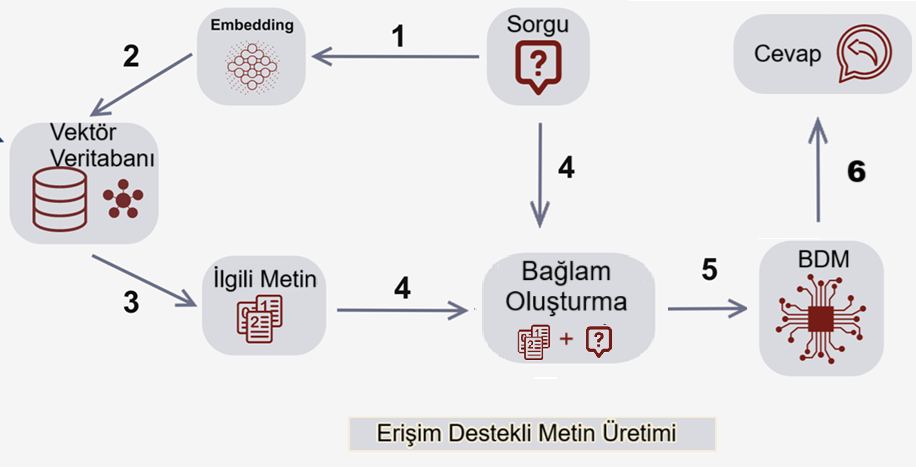

In [70]:
# Daha önceden hazırladığımız kullanıcı ve sistem yönlendirmelerini hatırlayalım:
print(system_prompt)
print(user_prompt)


You are a specialized academic assistant operating within a Retrieval-Augmented Generation (RAG) system. 
Your core mission is to assist TED University students by answering their academic 
and administrative questions **strictly based on the provided context passages**, 
which contain official university policies, rules, and procedures 
(e.g., student regulations, guidelines, directives).

Your role is not to offer opinions, make assumptions, or draw on general knowledge, 
but to **precisely interpret and communicate the rules** as they are written in the source materials.

You must adhere to the following directives without exception:

---

**1. Context-Only Grounding (No Hallucination)**

- You are only authorized to generate responses using the context documents provided with the user’s question.
- Do **not** use prior training data, world knowledge, personal judgment, 
or plausible assumptions under any circumstances.
- If the answer to the question **cannot be directly found or 

In [71]:
model_name= "gemini-2.0-flash"

chat = create_chat(system_prompt, model_name)

llm_answer= generate_answer(user_prompt)
display(Markdown(llm_answer))



Bu sorunun yanıtı elimdeki bilgilere göre belirlenemiyor.

In [72]:
llm_answer= generate_answer("Hangi metin parçasında yazıyor?")
display(Markdown(llm_answer))

"Bu sorunun yanıtı elimdeki bilgilere göre belirlenemiyor." ifadesi, bir cevap bulamadığım durumlarda kullandığım standart bir ifadedir ve herhangi bir metin parçasında yer almaz. Bu ifade, sağlanan bağlam belgelerinde sorunun cevabının doğrudan bulunmadığını belirtmek için kullanılır.

In [73]:
llm_answer= generate_answer("Şimdiye kadar sana hangi soruları sordum?")
display(Markdown(llm_answer))

Şu ana kadar bana sorduğun sorular şunlar:

1. Öğrencinin muafiyet hakkı kaç kere kullanılabilir?
2. Hangi metin parçasında yazıyor?



### 🎯 Bu Aşamanın Önemi

Bu adım, RAG mimarisinin en görünür sonucudur. Sistem, yalnızca dil modelinin eğitilmiş bilgisine değil; güncel, kaynaklı ve denetlenebilir içeriklere de dayanarak cevap üretmiştir. Bu sayede:

* Yanıtlar daha doğru ve güncel olur.
* Kaynak bilgileri açıkça sunulur.
* Modelin "halüsinasyon" üretme ihtimali düşer.


### 📌 Sonraki Adım

Artık RAG sisteminde veri erişimi, bağlam oluşturma ve cevap üretme adımlarını tamamladık. Bundan sonra bu yetkinlikleri bir araya getirerek tam teşekküllü bir **sohbet botu** geliştirmeye geçeceğiz.

Bir sonraki bölüm: **8. Sohbet Botunun Geliştirilmesi**


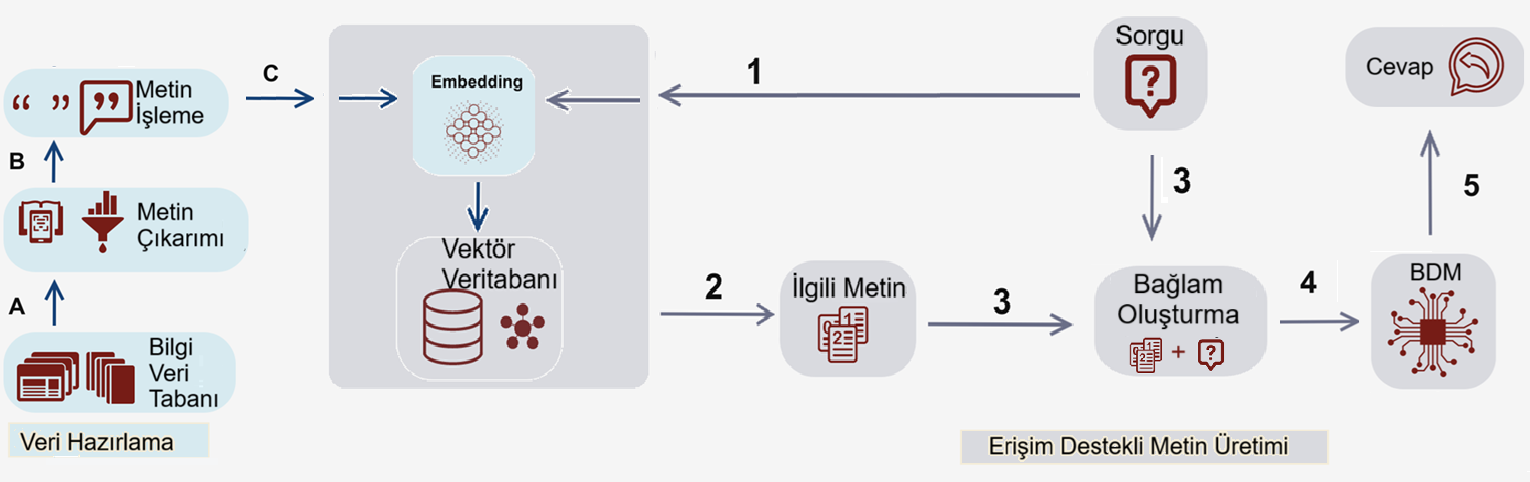
